In [7]:
import cv2
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time
import os

In [8]:
INPUT_IMAGE = "input.jpg"
MAX_DIM = 300                  # Максимальная сторона (px).
SIGMA = 0.05                   # Параметр функции сродства. Меньше = резкие границы цвета.
SCRIBBLE_RATIO = 0.01          # Доля пикселей

img = cv2.imread(INPUT_IMAGE)
if img is None:
    raise FileNotFoundError(f"Изображение {INPUT_IMAGE} не найдено.")

H, W = img.shape[:2]
scale = min(MAX_DIM / max(H, W), 1.0)
if scale < 1:
    new_W, new_H = int(W * scale), int(H * scale)
    img = cv2.resize(img, (new_W, new_H))
    H, W = new_H, new_W
    print(f"Изображение уменьшено до {W}x{H}.")

Изображение уменьшено до 300x190.


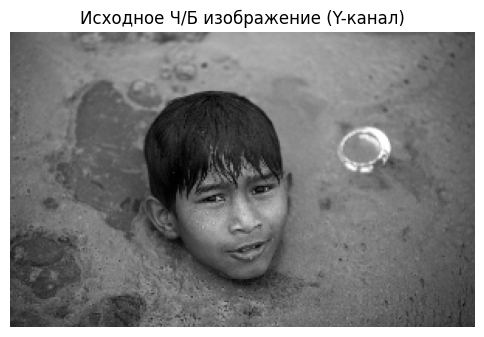

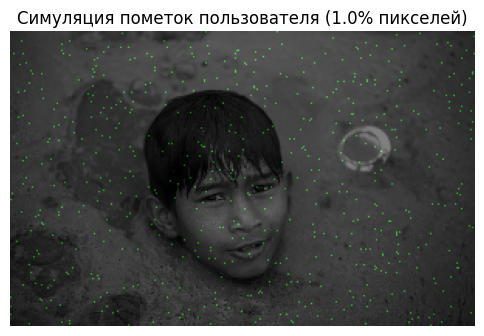

True

In [9]:
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
Y = img_yuv[:, :, 0].astype(np.float32) / 255.0
U_orig = img_yuv[:, :, 1].astype(np.float32) / 255.0
V_orig = img_yuv[:, :, 2].astype(np.float32) / 255.0

# Сохраняем Ч/Б версию
bw_img = np.stack([Y, Y, Y], axis=-1)
plt.figure(figsize=(6, 6))
plt.imshow(bw_img, cmap='gray')
plt.title("Исходное Ч/Б изображение (Y-канал)")
plt.axis('off')
plt.show()

# Генерация случайных "пометок"
num_pixels = H * W
num_scribbles = int(num_pixels * SCRIBBLE_RATIO)
scribble_idx = np.random.choice(num_pixels, num_scribbles, replace=False)

U_target = np.zeros(num_pixels, dtype=np.float32)
V_target = np.zeros(num_pixels, dtype=np.float32)
U_target[scribble_idx] = U_orig.flatten()[scribble_idx]
V_target[scribble_idx] = V_orig.flatten()[scribble_idx]

is_scribble = np.zeros(num_pixels, dtype=bool)
is_scribble[scribble_idx] = True

# Визуализация пометок
scribble_mask = np.zeros((H, W, 3), dtype=np.uint8)
scribble_mask.reshape(-1, 3)[is_scribble] = [0, 255, 0]  # Зеленые точки
plt.figure(figsize=(6, 6))
plt.imshow(bw_img, cmap='gray')
plt.imshow(scribble_mask, alpha=0.5)
plt.title(f"Симуляция пометок пользователя ({SCRIBBLE_RATIO*100:.1f}% пикселей)")
plt.axis('off')
plt.show()

cv2.imwrite("bw_output.jpg", (Y * 255).astype(np.uint8))

bw_img_uint8 = (np.stack([Y, Y, Y], axis=-1) * 255).astype(np.uint8)
result = bw_img_uint8.copy()
result.reshape(-1, 3)[is_scribble] = [0, 255, 0]
cv2.imwrite("dirichle_output.jpg", result)

In [10]:
L = lil_matrix((num_pixels, num_pixels), dtype=np.float32)
Y_flat = Y.flatten()
# 8-связная окрестность
neighbors = [(-1,0), (1,0), (0,-1), (0,1), (-1,-1), (-1,1), (1,-1), (1,1)]

t_start = time.time()
for y in range(H):
    for x in range(W):
        idx = y * W + x
        
        if is_scribble[idx]:
            L[idx, idx] = 1.0
            continue
            
        val_y = Y_flat[idx]
        n_idx_list = []
        w_list = []
        
        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W:
                n_idx = ny * W + nx
                diff = (val_y - Y_flat[n_idx])**2
                w = np.exp(-diff / (2 * SIGMA**2))
                n_idx_list.append(n_idx)
                w_list.append(w)
        
        w_sum = sum(w_list)
        if w_sum > 1e-6:
            w_norm = np.array(w_list) / w_sum
            L[idx, idx] = 1.0
            for n_idx, w in zip(n_idx_list, w_norm):
                L[idx, n_idx] -= w
        else:
            L[idx, idx] = 1.0

    if y % 50 == 0:
        print(f"   Обработано строк: {y}/{H} ({time.time()-t_start:.1f} сек)")

L_csr = L.tocsr()
print(f"Матрица построена за {time.time()-t_start:.1f} сек. Размер: {L_csr.shape}")

   Обработано строк: 0/190 (0.0 сек)
   Обработано строк: 50/190 (0.6 сек)
   Обработано строк: 100/190 (1.3 сек)
   Обработано строк: 150/190 (1.9 сек)
Матрица построена за 2.5 сек. Размер: (57000, 57000)


In [11]:
print("СЛАУ")
t_solve = time.time()
U_sol = spsolve(L_csr, U_target)
V_sol = spsolve(L_csr, V_target)
print(f"{time.time()-t_solve:.2f} сек.")

U_res = np.clip(U_sol, 0.0, 1.0).reshape(H, W)
V_res = np.clip(V_sol, 0.0, 1.0).reshape(H, W)

yuv_result = cv2.merge([Y*255, U_res*255, V_res*255]).astype(np.uint8)
bgr_result = cv2.cvtColor(yuv_result, cv2.COLOR_YUV2BGR)

cv2.imwrite("restored_output.jpg", bgr_result)
print("restored_output.jpg")

СЛАУ
0.77 сек.
restored_output.jpg


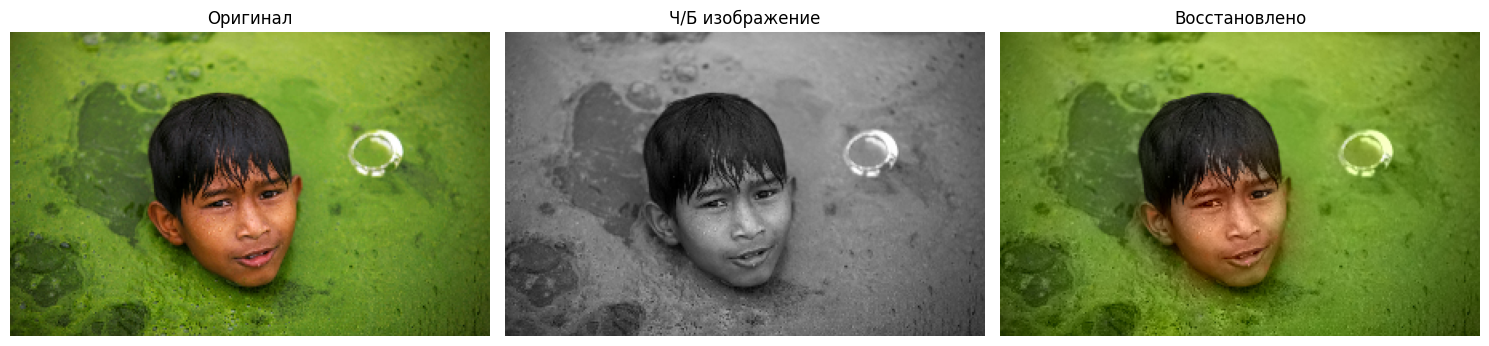

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Оригинал")
axes[0].axis('off')

axes[1].imshow(bw_img, cmap='gray')
axes[1].set_title("Ч/Б изображение")
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(bgr_result, cv2.COLOR_BGR2RGB))
axes[2].set_title("Восстановлено")
axes[2].axis('off')

plt.tight_layout()
plt.show()